# Anomaly Detection — 4 Confirmed Clusters

Rule-based investigation: each cluster is isolated with a boolean condition, profiled, and checked for a concentrated "fingerprint" (constant magnitude, single time window, single PSP) that separates a real anomaly from ordinary noise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                      'axes.spines.right': False, 'figure.facecolor': 'white'})

DATA_PATH = '/home/veronika/Anomaly_Hunter_Solidgate/hackathon_int20h_dataset_test.csv'

df = pd.read_csv(DATA_PATH)
df['created_at'] = pd.to_datetime(df['created_at'])
df['processed_at'] = pd.to_datetime(df['processed_at'])
df['latency_sec'] = (df['processed_at'] - df['created_at']).dt.total_seconds()
df['is_fail'] = (df['status'] == 'fail').astype(int)
df['week'] = df['created_at'].dt.to_period('W').astype(str)

## 1. `bank_id == 777` — synthetic block

In [2]:
c777 = df[df['bank_id'] == 777]
dur = (c777['processed_at'] - c777['created_at']).dt.total_seconds()

print(f"Rows: {len(c777)}  |  Unique dates: {c777['created_at'].dt.date.nunique()}"
      f"  |  Fail rate: {(c777['status']=='fail').mean():.0%}"
      f"  |  Latency: constant {dur.iloc[0]:.0f}s (std={dur.std():.4f})")

Rows: 635  |  Unique dates: 1  |  Fail rate: 100%  |  Latency: constant 5s (std=0.0000)


- all 635 rows created on a **single calendar day**, `bank_id` format (3 digits) doesn't match any other bank
- **100% fail**, **exactly 5.0s latency with zero variance** — no real network process behaves like this
- **verdict: synthetically inserted block**

## 2. `psp_gamma` — latency incident

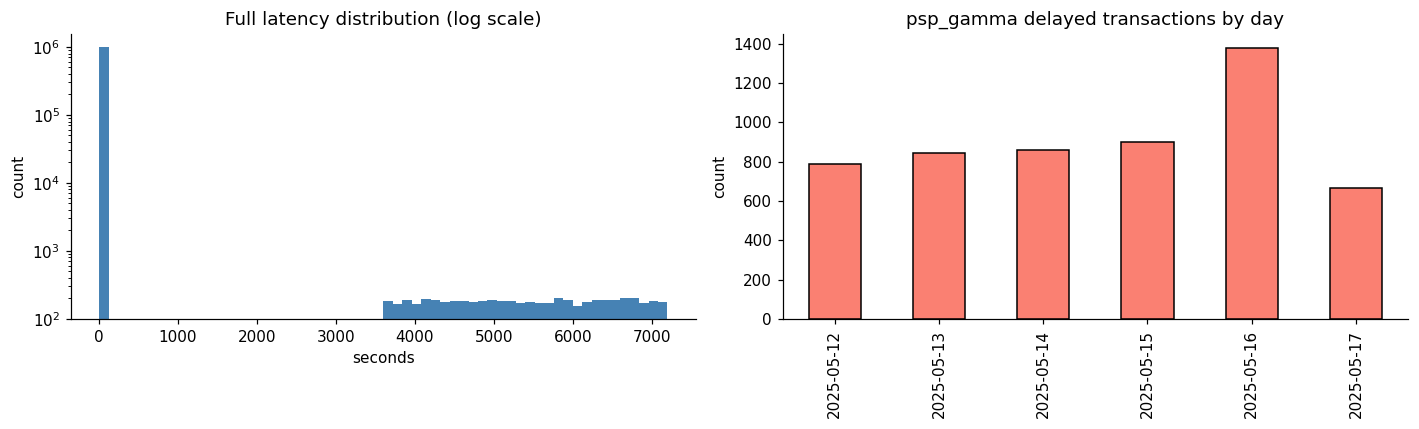

Delayed rows: 5,433 (0.54% of dataset)  |  100% psp_gamma, 12-17 May 2025
Fail rate in window: 46.59%  vs  dataset baseline: 47.49%  (no meaningful difference)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['latency_sec'], bins=60, color='steelblue', edgecolor='none')
axes[0].set_yscale('log')
axes[0].set(title='Full latency distribution (log scale)', xlabel='seconds', ylabel='count')

window = df[(df['psp_id'] == 'psp_gamma') & (df['created_at'].between('2025-05-12', '2025-05-17 23:59:59'))]
window['created_at'].dt.date.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set(title='psp_gamma delayed transactions by day', xlabel='', ylabel='count')
plt.tight_layout(); plt.show()

fail_in = (window['status'] == 'fail').mean()
fail_all = (df['status'] == 'fail').mean()
print(f"Delayed rows: {len(window):,} ({len(window)/len(df):.2%} of dataset)  |  100% psp_gamma, 12-17 May 2025")
print(f"Fail rate in window: {fail_in:.2%}  vs  dataset baseline: {fail_all:.2%}  (no meaningful difference)")

- clean gap in the distribution: <10s (99.5%) vs 1-2h (0.54%), nothing in between
- concentrated in **one PSP, one 6-day window**, gradual degrade/recover shape (not instant on/off)
- fail rate inside the window matches the global baseline — the delay itself doesn't cause failures
- **verdict: real provider-side operational outage**, not synthetic

## 3. `psp_beta` — over-refund (+10 flat)

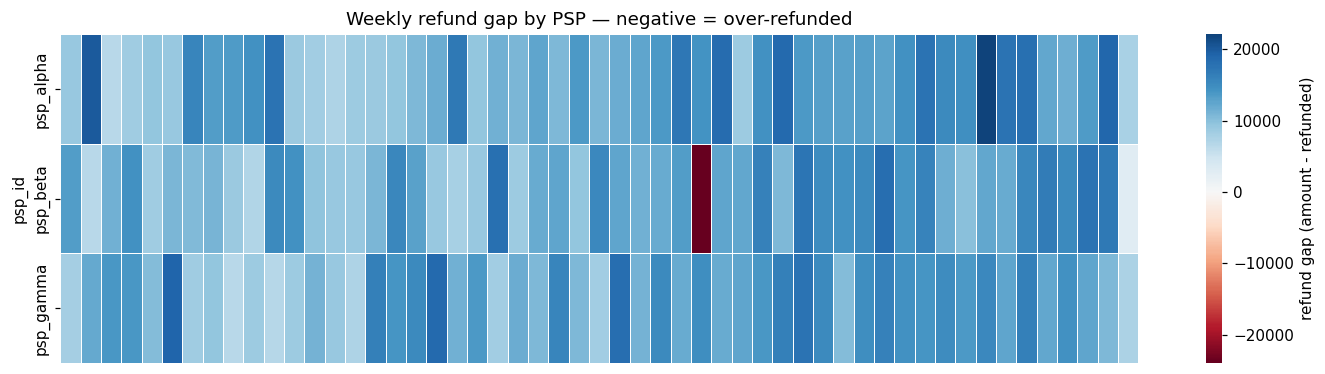

Over-refunded rows (refunded_amount > amount): 2,691, all inside 5-9 Aug 2025, all psp_beta
Gap is a flat +10 in every currency (unique gap values: 1)
66 of these rows have status == 'fail' — a failed payment cannot be refunded


In [4]:
refunds = df[df['has_refund']].copy()
refunds['gap'] = refunds['amount'] - refunds['refunded_amount']
pivot = refunds.pivot_table(values='gap', index='psp_id', columns='week', aggfunc='sum')

plt.figure(figsize=(13, 3.5))
sns.heatmap(pivot, cmap='RdBu', center=0, linewidths=0.4, cbar_kws={'label': 'refund gap (amount - refunded)'})
plt.title('Weekly refund gap by PSP — negative = over-refunded'); plt.xlabel(''); plt.xticks([])
plt.tight_layout(); plt.show()

over = df[df['refunded_amount'] > df['amount']]
gap_vals = (over['refunded_amount'] - over['amount']).round(2)
print(f"Over-refunded rows (refunded_amount > amount): {len(over):,}, all inside 5-9 Aug 2025, all psp_beta")
print(f"Gap is a flat +{gap_vals.mode()[0]:.0f} in every currency (unique gap values: {gap_vals.nunique()})")
print(f"{(over['status']=='fail').sum()} of these rows have status == 'fail' — a failed payment cannot be refunded")

- 2,691 rows, **100% of the year's over-refund cases** fall in a single 5-day window (5-9 Aug), 100% `psp_beta`
- gap is a **flat +10 regardless of currency** — a real business rule would scale with currency, not add a constant
- 66 rows (2.4%) are refunds on **failed** transactions — a logical impossibility
- **verdict: synthetically inserted / corrupted financial data**

## 4. Refund on a failed transaction — 0.5x ratio

In [5]:
fr = df[df['has_refund'] & (df['status'] == 'fail')].copy()
fr['ratio'] = fr['refunded_amount'] / fr['amount']
half = (fr['ratio'] == 0.5).mean()

print(f"has_refund=True & status=='fail': {len(fr):,} rows, spread across all 12 months, all 3 PSPs")
print(f"Exact refunded_amount == 0.5 x amount: {half:.1%} of this cluster")
print(fr['psp_id'].value_counts().rename('rows').to_frame().T)

has_refund=True & status=='fail': 1,299 rows, spread across all 12 months, all 3 PSPs
Exact refunded_amount == 0.5 x amount: 94.0% of this cluster
psp_id  psp_alpha  psp_beta  psp_gamma
rows          690       352        257


- a failed payment collected no money, so any refund on it is a hard-invariant violation — valid regardless of timing
- **94% have `refunded_amount` at exactly half of `amount`** — a hardcoded ratio, not noise
- skewed toward `applepay` (63% of this cluster vs ~15% of the dataset); 66 rows overlap the psp_beta window above via a different mechanism (+10 vs 0.5x)
- **verdict: synthetically inserted, not time-bound**

## Ruled out — investigated, not flagged

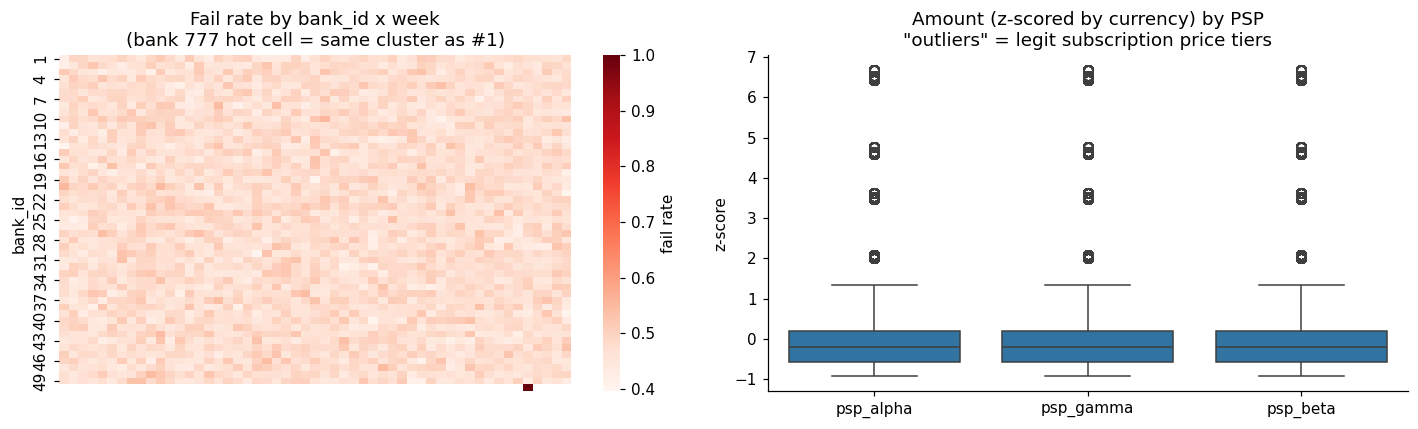

ip_country != bin_country: 14.4% baseline, explained by NA-vs-rest customer geography, no time/category spike
psp_alpha fail rate: 48.9% vs other PSPs 46.8% — systemic all year, not a point incident


In [6]:
pivot_fail = df.pivot_table(values='is_fail', index='bank_id', columns='week', aggfunc='mean')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(pivot_fail, cmap='Reds', ax=axes[0], cbar_kws={'label': 'fail rate'})
axes[0].set(title='Fail rate by bank_id x week\n(bank 777 hot cell = same cluster as #1)', xlabel='', ylabel='bank_id')
axes[0].set_xticks([])

df['amount_z'] = df.groupby('currency')['amount'].transform(lambda x: (x - x.mean()) / x.std())
sns.boxplot(x='psp_id', y='amount_z', data=df, ax=axes[1])
axes[1].set(title='Amount (z-scored by currency) by PSP\n"outliers" = legit subscription price tiers', xlabel='', ylabel='z-score')
plt.tight_layout(); plt.show()

mismatch = (df['ip_country'] != df['bin_country']).mean()
alpha_fail = df[df['psp_id']=='psp_alpha']['is_fail'].mean()
other_fail = df[df['psp_id']!='psp_alpha']['is_fail'].mean()
print(f"ip_country != bin_country: {mismatch:.1%} baseline, explained by NA-vs-rest customer geography, no time/category spike")
print(f"psp_alpha fail rate: {alpha_fail:.1%} vs other PSPs {other_fail:.1%} — systemic all year, not a point incident")

- **`ip_country`/`bin_country` mismatch** (14.4%) — stable demographic pattern (home-market card loyalty), no concentration
- **amount "outliers" per category** — a fixed, currency-converted subscription price ladder (7-10 tiers), 100% `order_type == recurring`
- **`psp_alpha`'s higher fail rate** — real but spans a third of the whole dataset all year; too broad to be a point anomaly under a high-imbalance premise
- zero-amount transactions: 0 occurrences

All three are statistically distinctive but explainable — kept as background context, not `is_anomaly` signals.

## Summary

| Cluster | Rows | Window | Signature | Nature |
|---|---|---|---|---|
| `bank_id == 777` | 635 | 1 day | constant 5s latency, 100% fail | synthetic block |
| psp_gamma latency | 5,433 | 6 days | 1-2h delay, gradual degrade/recover | real outage |
| psp_beta over-refund | 2,691 | 5 days | flat +10 in every currency | synthetic/corrupted |
| fail + refund | 1,299 | all year | 94% exact 0.5x ratio | synthetic, not time-bound |

Continue to `03_ml_scoring.ipynb` for an unsupervised cross-check.